In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import ast
from datasets import load_dataset
from adjustText import adjust_text

datas = load_dataset('lukebarousse/data_jobs')

df = datas['train'].to_pandas()
# df = pd.read_csv('../data_jobs.csv')

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)
countries = ['Denmark','Netherlands','Sweden','Norway','Belgium','Luxemburg','Ireland']
european_countries = [
    # Western Europe
    'Austria', 'Belgium', 'France', 'Germany', 'Liechtenstein', 
    'Luxembourg', 'Monaco', 'Netherlands', 'Switzerland',
    
    # Northern Europe & Nordics / Baltics
    'Denmark', 'Estonia', 'Finland', 'Iceland', 'Ireland', 
    'Latvia', 'Lithuania', 'Norway', 'Sweden', 'United Kingdom',
    
    # Southern Europe
    'Albania', 'Andorra', 'Bosnia and Herzegovina', 'Croatia', 'Cyprus', 
    'Gibraltar', 'Greece', 'Italy', 'Malta', 'Montenegro', 
    'North Macedonia', 'Portugal', 'San Marino', 'Serbia', 'Slovenia', 'Spain',
    
    # Eastern Europe & Transcontinental
    'Armenia', 'Azerbaijan', 'Belarus', 'Bulgaria', 'Czechia', 
    'Czech Republic', 'Georgia', 'Hungary', 'Kazakhstan', 'Moldova', 
    'Poland', 'Romania', 'Russia', 'Slovakia', 'Turkey', 'Ukraine'
]
dfe = df[df['job_country'].isin(european_countries)]
jobs = sorted([
 'Data Engineer',
 'Senior Data Engineer',
 'Data Scientist',
 'Senior Data Scientist'
 ])
dfe = dfe[dfe["job_title_short"].isin(jobs)].copy()
dfe = dfe.dropna(subset='salary_year_avg')

In [19]:

dfex = dfe.explode('job_skills')
dfeg = dfex.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

dfegt = dfeg.sort_values('median',ascending=False).head(10)
dfegs = dfeg.sort_values('count',ascending=False).head(10).sort_values('median',ascending=False)
dfegs


,count,median
job_skills,,
kafka,148,147500.0
spark,333,147500.0
tableau,151,147500.0
airflow,170,147500.0
aws,368,134241.0
sql,628,133000.0
python,736,132500.0
gcp,145,132500.0
azure,244,131580.0


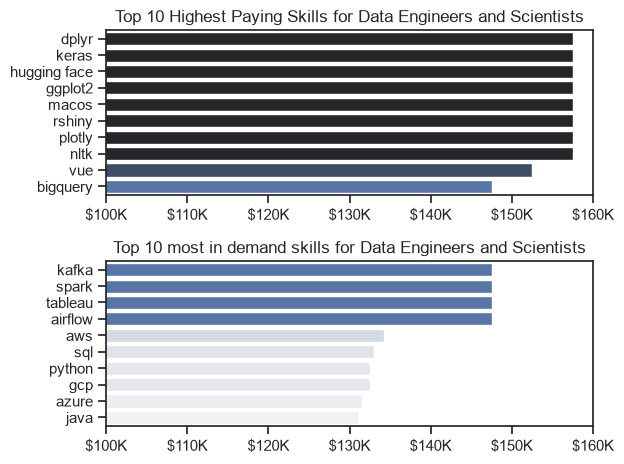

In [20]:
import seaborn as sns
fig, ax = plt.subplots(2,1)
sns.set_theme(style="ticks")
sns.barplot(data=dfegt, x='median',y=dfegt.index,ax=ax[0],hue='median',palette='dark:b_r')
# dfegt.plot(kind='barh', y='median',ax=ax[0],title='Top 10 Highest Paying Skills for Data Engineers')
# ax[0].invert_yaxis()
ax[0].legend().set_visible(False)
ax[0].set_title('Top 10 Highest Paying Skills for Data Engineers and Scientists')
ax[0].set_ylabel('')
ax[0].set_xlim(100_000, 160_000)
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000)}K'))

sns.barplot(data=dfegs, x='median',y=dfegs.index,ax=ax[1],hue='median', palette='light:b')
# dfegs.plot(kind='barh', y='median',ax=ax[1],title='Top 10 most in demand skills for Data Engineers')
ax[1].set_title('Top 10 most in demand skills for Data Engineers and Scientists')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000)}K'))
ax[1].legend().set_visible(False)
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].set_xlim(100_000, 160_000)

fig.tight_layout()
plt.show()

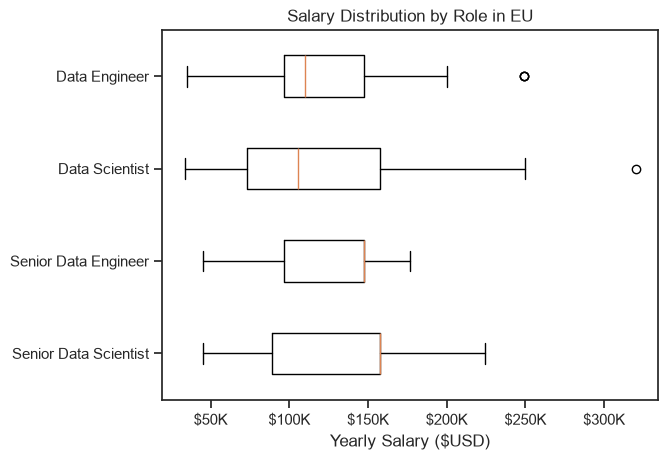

In [21]:
job_list = [dfe[dfe['job_title_short']==job]['salary_year_avg'] for job in jobs]
plt.boxplot(job_list,tick_labels=sorted(jobs),orientation='horizontal')
ax = plt.gca()
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))
plt.title('Salary Distribution by Role in EU')
plt.xlabel('Yearly Salary ($USD)')
plt.show()

In [79]:
dfegs = dfeg.sort_values('count',ascending=False)

dfegs['skill_percent'] = dfegs['count'] / len(dfe) * 100
dfegh = dfegs[dfegs['skill_percent'] > 13]
dfegh

,count,median,skill_percent
job_skills,,,
python,736,132500.0,64.000000
sql,628,133000.0,54.608696
aws,368,134241.0,32.000000
spark,333,147500.0,28.956522
azure,244,131580.0,21.217391
java,173,131193.0,15.043478
airflow,170,147500.0,14.782609
tableau,151,147500.0,13.130435


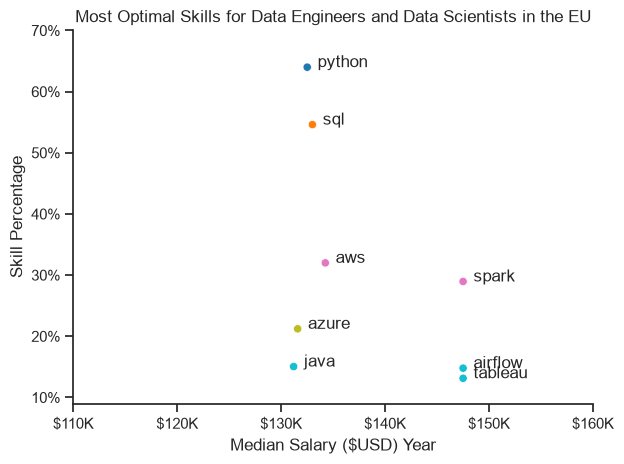

In [84]:
# dfegh.plot(kind='scatter',x='skill_percent',y='median')
sns.set_theme(style='ticks')
sns.scatterplot(data=dfegh,x='median',y='skill_percent',hue='skill_percent',palette='tab10_r',legend=False)
texts=[]    
for i,txt in enumerate(dfegh.index):
    texts.append(plt.text(dfegh['median'].iloc[i]+1000,dfegh['skill_percent'].iloc[i],txt))

# adjust_text(texts, arrowprops=dict(arrowstyle='->',color='gray',lw=5))
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:f'${int(y/1000)}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'{int(x)}%'))
plt.xlim(110_000,160_000)
plt.ylim(9,70)
plt.title('Most Optimal Skills for Data Engineers and Data Scientists in the EU')
plt.xlabel('Median Salary ($USD) Year')
plt.ylabel('Skill Percentage')
sns.despine()
plt.tight_layout()
plt.show()